# Diamond RCA - Project Setup and Initial Data Pull
This notebook demonstrates basic path setup, a small data pull, local save, and a simple rolling metric plot.

In [1]:
from diamond_rca.analysis.collapse_definition import compute_rolling_win_pct
from diamond_rca.data.extract import fetch_team_batting_data
from diamond_rca.data.savers import save_csv
from diamond_rca.paths import RAW_DATA_DIR, ensure_project_dirs
from diamond_rca.viz.plots import plot_rolling_metric

ensure_project_dirs()
RAW_DATA_DIR

PosixPath('/workspaces/DiamondRCA/data/raw')

In [2]:
batting_df = fetch_team_batting_data(season=2025, team='NYM')
batting_df.head()

,IDfg,Season,Name,Team,Age,G,AB,PA,H,1B,...,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR
76,12916,2025,Francisco Lindor,NYM,31,160,644,732,172,106,...,112.9,231.0,0.444,520,0.162,0.252,0.260,0.454,0.345,6.2
15,20123,2025,Juan Soto,NYM,26,160,577,715,152,88,...,115.0,247.0,0.551,448,0.212,0.281,0.288,0.608,0.429,6.2
30,19251,2025,Pete Alonso,NYM,30,162,624,709,170,90,...,115.9,256.0,0.544,471,0.163,0.269,0.274,0.572,0.386,4.0
155,12927,2025,Brandon Nimmo,NYM,32,155,587,652,154,102,...,112.3,228.0,0.502,454,0.171,0.273,0.252,0.419,0.321,3.0
173,26123,2025,Brett Baty,NYM,25,130,393,432,100,67,...,115.6,135.0,0.467,289,0.167,0.277,0.252,0.457,0.334,2.4


In [3]:
if not batting_df.empty:
    out_path = save_csv(batting_df, RAW_DATA_DIR / 'nym_2025_batting.csv')
    print(f'Saved to: {out_path}')
else:
    print('No batting data returned (network/source issue is possible).')

Saved to: /workspaces/DiamondRCA/data/raw/nym_2025_batting.csv


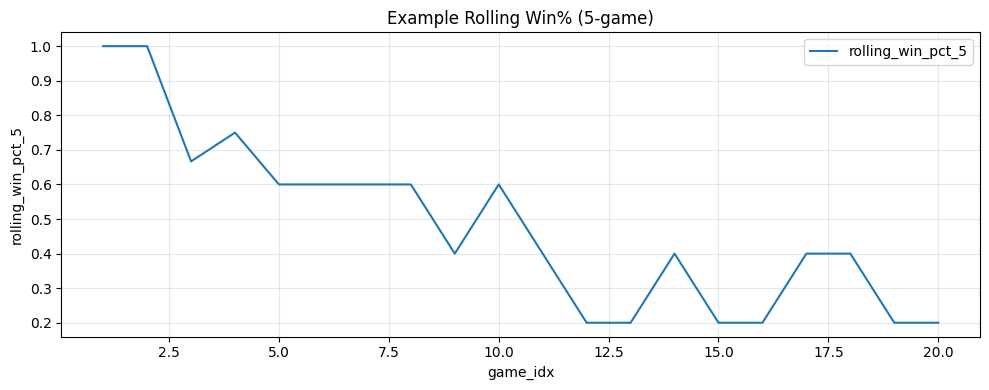

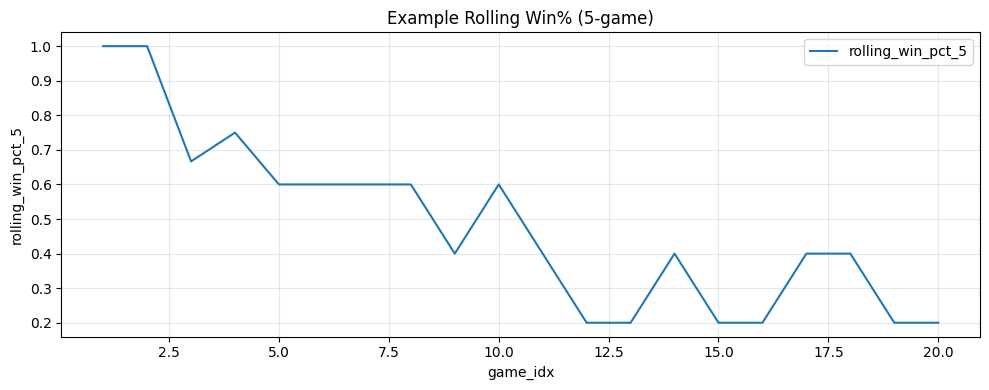

In [4]:
import pandas as pd

example_games = pd.DataFrame({
    'game_idx': list(range(1, 21)),
    'is_win': [1,1,0,1,0,1,1,0,0,1, 0,0,0,1,0,0,1,0,0,0],
})
example_games['rolling_win_pct_5'] = compute_rolling_win_pct(example_games, window=5)
fig, ax = plot_rolling_metric(example_games, x_col='game_idx', y_col='rolling_win_pct_5', title='Example Rolling Win% (5-game)')
fig